In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
train_test_sets = joblib.load('../../data/processed/train_test_sets.pkl')
X_train, X_test, y_train, y_test = train_test_sets['A1_CART']
 
print(f"\n  Train: {X_train.shape} | Test: {X_test.shape}")


  Train: (10811, 3) | Test: (4634, 3)


## CART - ANALIZA A1

-   Variabile: PageValues, BounceRates, VisitorType

### Arbore FARA PRUNING (de referinta)

In [3]:
cart_full = DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    random_state=7
)
cart_full.fit(X_train, y_train)
 
print(f"\n── 8.1 ARBORE FĂRĂ PRUNING ──")
print(f"Adâncime maximă : {cart_full.get_depth()}")
print(f"Număr noduri : {cart_full.tree_.node_count}")
print(f"Număr frunze: {cart_full.get_n_leaves()}")
print(f"Accuracy train : {cart_full.score(X_train, y_train):.4f}")
print(f"Accuracy test: {cart_full.score(X_test, y_test):.4f}")
overfitting = cart_full.score(X_train, y_train) - cart_full.score(X_test, y_test)
print(f"Diferență (overfit): {overfitting:.4f} {'overfit boss' if overfitting > 0.05 else 'ok boss'}")


── 8.1 ARBORE FĂRĂ PRUNING ──
Adâncime maximă : 45
Număr noduri : 2835
Număr frunze: 1418
Accuracy train : 0.9753
Accuracy test: 0.8487
Diferență (overfit): 0.1266 overfit boss


### PRUNING – Cost Complexity (ccp_alpha)

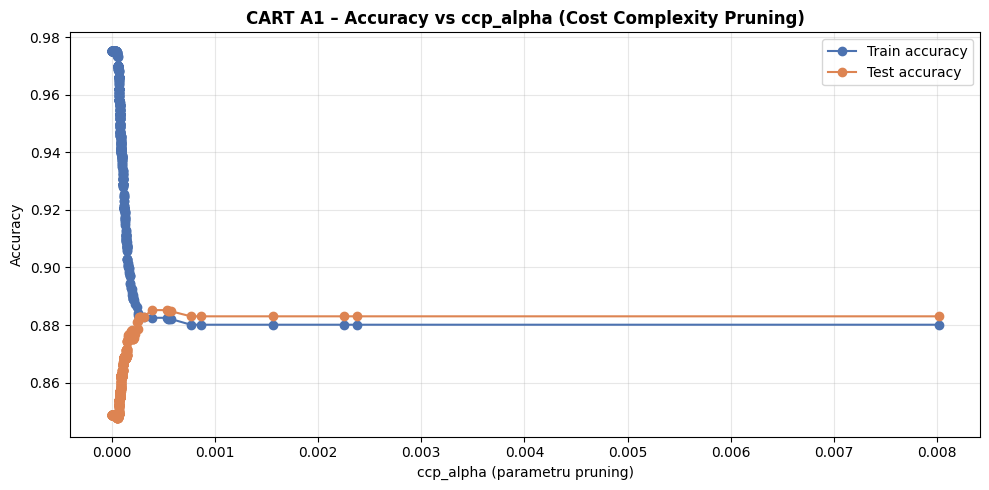

Alpha optim ales : 0.000390


In [4]:
path = cart_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  ## elim ultimul (arborele gol)
 
## Antrenam un arbore pentru fiecare alpha
train_scores, test_scores = [], []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='gini', ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))
 
## Vizualizare alpha vs accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas, train_scores, 'o-', label='Train accuracy', color='#4C72B0')
ax.plot(ccp_alphas, test_scores,  'o-', label='Test accuracy',  color='#DD8452')
ax.set_xlabel('ccp_alpha (parametru pruning)')
ax.set_ylabel('Accuracy')
ax.set_title('CART A1 – Accuracy vs ccp_alpha (Cost Complexity Pruning)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
## Alegem alpha optim = cel care maxim test accuracy
best_alpha = ccp_alphas[np.argmax(test_scores)]
print(f"Alpha optim ales : {best_alpha:.6f}")

In [6]:
cart_pruned = DecisionTreeClassifier(
    criterion='gini',
    ccp_alpha=best_alpha,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=7
)
cart_pruned.fit(X_train, y_train)
 
print(f"Adâncime maximă: {cart_pruned.get_depth()}")
print(f"Număr noduri : {cart_pruned.tree_.node_count}")
print(f"Număr frunze : {cart_pruned.get_n_leaves()}")
print(f"Accuracy train: {cart_pruned.score(X_train, y_train):.4f}")
print(f"Accuracy test: {cart_pruned.score(X_test, y_test):.4f}")

Adâncime maximă: 5
Număr noduri : 27
Număr frunze : 14
Accuracy train: 0.8813
Accuracy test: 0.8839


### Vizualizarea arborelui

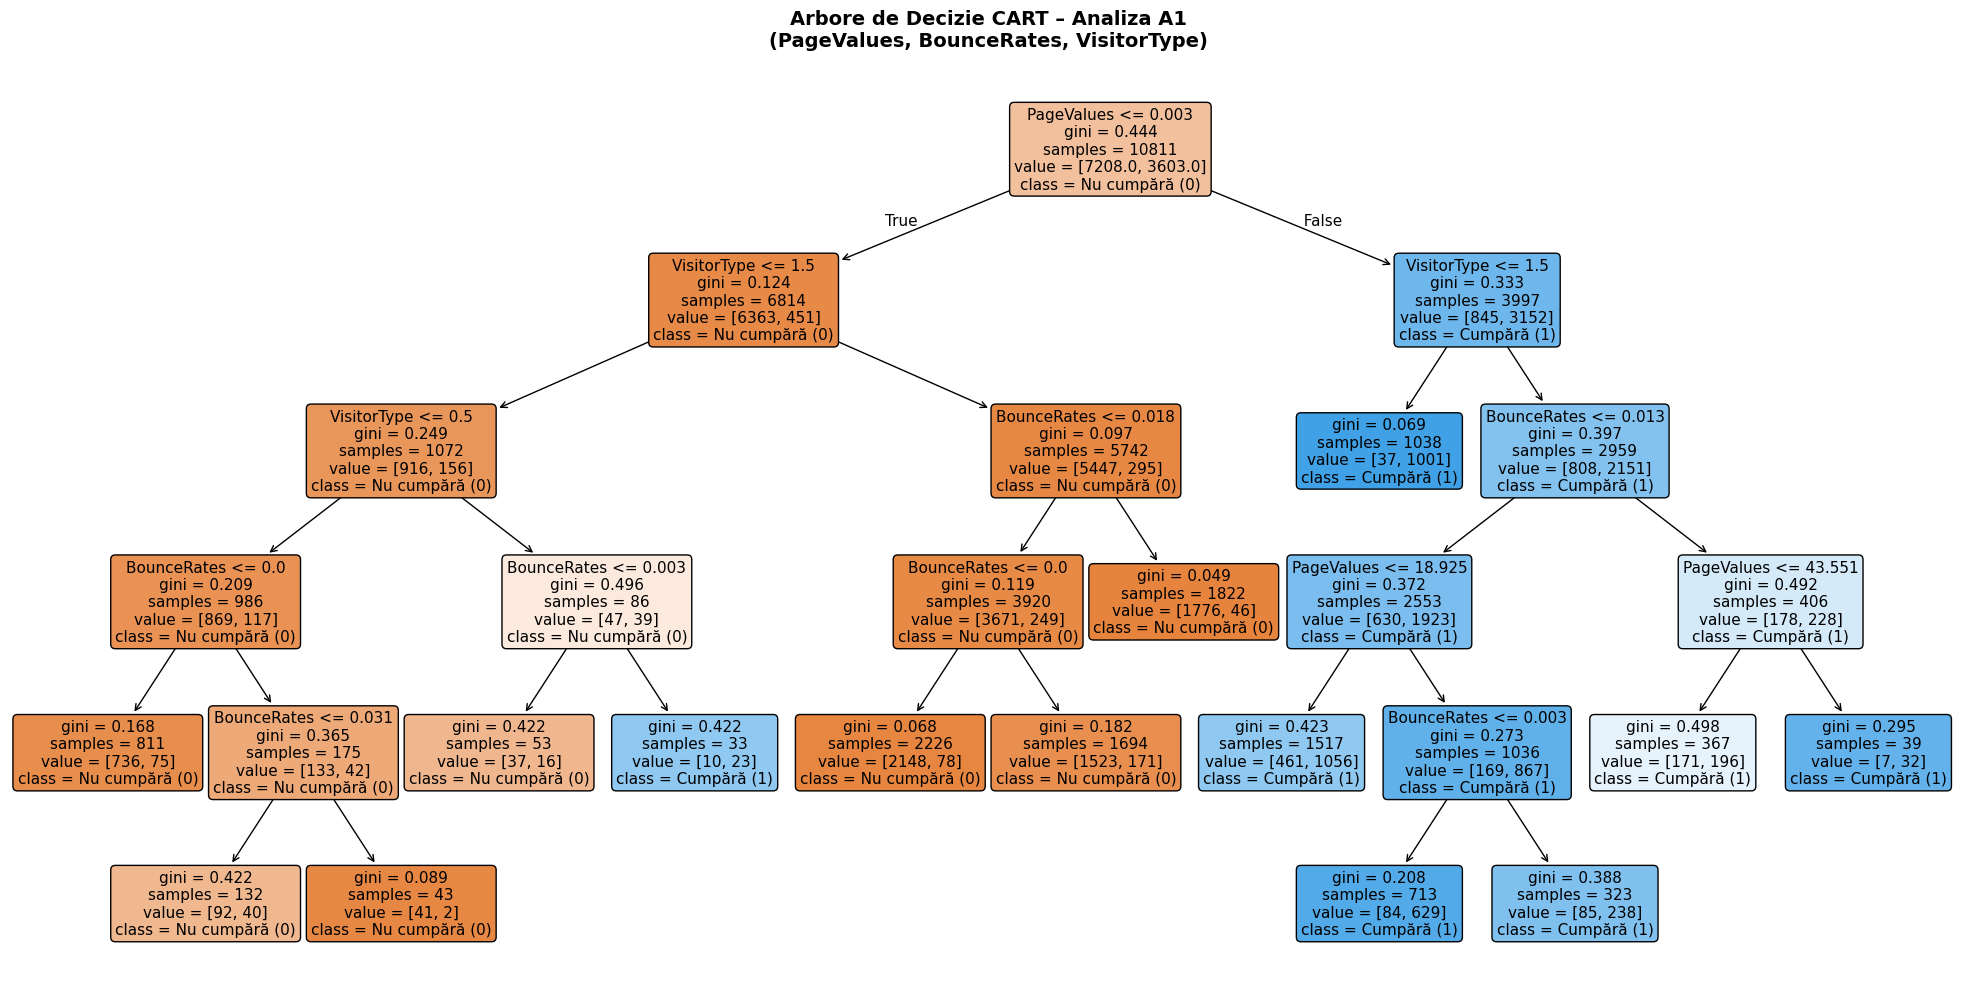

In [7]:
feature_names = X_train.columns.tolist()
class_names   = ['Nu cumpără (0)', 'Cumpără (1)']
 
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(cart_pruned,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=11,
          ax=ax,
          impurity=True,
          proportion=False)
ax.set_title('Arbore de Decizie CART – Analiza A1\n(PageValues, BounceRates, VisitorType)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Evaluarea modelului

In [10]:
y_pred = cart_pruned.predict(X_test)
y_pred_prob = cart_pruned.predict_proba(X_test)[:, 1]
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
auc = roc_auc_score(y_test, y_pred_prob)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
 
print(f"\nMETRICI DE PERFORMANȚĂ:")
print(f"{'Accuracy':<20}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"{'Precision':<20}: {precision:.4f}")
print(f"{'Recall (Sensitivity)':<20}: {recall:.4f}")
print(f"{'Specificity':<20}: {specificity:.4f}")
print(f"{'F1-Score':<20}: {f1:.4f}")
print(f"{'AUC-ROC':<20}: {auc:.4f}")
 
# Cross-validation
cv_scores = cross_val_score(cart_pruned, X_train, y_train, cv=10, scoring='f1')
print(f"\nCROSS-VALIDATION (10-fold) F1:")
print(f"Scoruri: {cv_scores.round(4)}")
print(f"Medie  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


METRICI DE PERFORMANȚĂ:
Accuracy            : 0.8839  (88.39%)
Precision           : 0.7946
Recall (Sensitivity): 0.8790
Specificity         : 0.8864
F1-Score            : 0.8347
AUC-ROC             : 0.9226

CROSS-VALIDATION (10-fold) F1:
Scoruri: [0.8529 0.8351 0.8268 0.8373 0.8211 0.8158 0.8349 0.8288 0.8132 0.8292]
Medie  : 0.8295 ± 0.0109


### Vizualizari evaluare

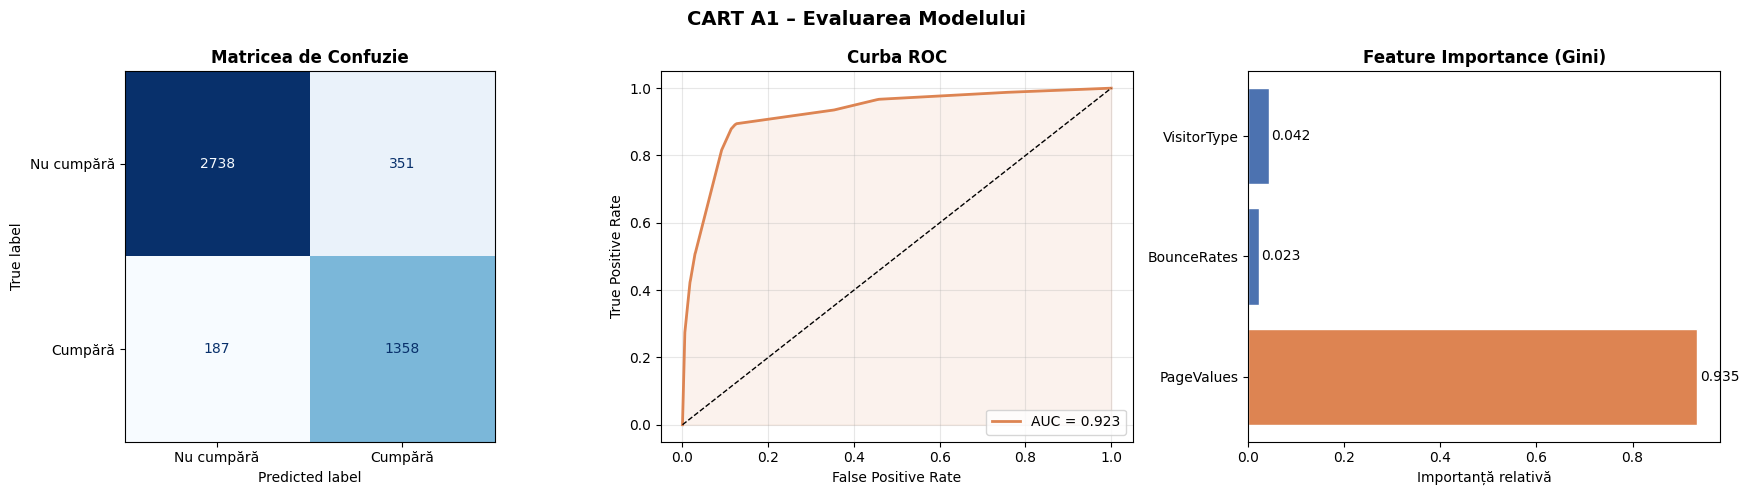

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CART A1 – Evaluarea Modelului', fontsize=14, fontweight='bold')
 
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Nu cumpără', 'Cumpără'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matricea de Confuzie', fontweight='bold')
 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#DD8452')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curba ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
 
importances = cart_pruned.feature_importances_
axes[2].barh(feature_names, importances,
             color=['#DD8452' if i == np.argmax(importances) else '#4C72B0'
                    for i in range(len(importances))],
             edgecolor='white')
axes[2].set_title('Feature Importance (Gini)', fontweight='bold')
axes[2].set_xlabel('Importanță relativă')
for i, v in enumerate(importances):
    axes[2].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

### Extragerea regulilor

In [12]:
rules = export_text(cart_pruned, feature_names=feature_names)
print(rules)

|--- PageValues <= 0.00
|   |--- VisitorType <= 1.50
|   |   |--- VisitorType <= 0.50
|   |   |   |--- BounceRates <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- BounceRates >  0.00
|   |   |   |   |--- BounceRates <= 0.03
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BounceRates >  0.03
|   |   |   |   |   |--- class: 0
|   |   |--- VisitorType >  0.50
|   |   |   |--- BounceRates <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- BounceRates >  0.00
|   |   |   |   |--- class: 1
|   |--- VisitorType >  1.50
|   |   |--- BounceRates <= 0.02
|   |   |   |--- BounceRates <= 0.00
|   |   |   |   |--- class: 0
|   |   |   |--- BounceRates >  0.00
|   |   |   |   |--- class: 0
|   |   |--- BounceRates >  0.02
|   |   |   |--- class: 0
|--- PageValues >  0.00
|   |--- VisitorType <= 1.50
|   |   |--- class: 1
|   |--- VisitorType >  1.50
|   |   |--- BounceRates <= 0.01
|   |   |   |--- PageValues <= 18.92
|   |   |   |   |--- class: 1
|   |   |   |--- PageValues >  18.

### Salvare model + rezultate

In [13]:
joblib.dump(cart_pruned, '../../data/processed/cart_a1_model.pkl')

['../../data/processed/cart_a1_model.pkl']

In [14]:
results_a1 = {
    'model': 'CART', 'analiza': 'A1',
    'features': feature_names,
    'depth': cart_pruned.get_depth(),
    'n_leaves': cart_pruned.get_n_leaves(),
    'accuracy': round(accuracy, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1': round(f1, 4),
    'auc': round(auc, 4),
    'cv_f1_mean': round(cv_scores.mean(), 4),
    'cv_f1_std': round(cv_scores.std(), 4)
}
 
pd.DataFrame([results_a1]).to_csv('../../outputs/cart_a1_results.csv', index=False)
 

### OBS:

-   AUC de 0.92 pe doar 3 variabile -> very nice

-   PageValues e extrem de discriminant


### CHAID - ANALIZA A2

-   Variabile: ExitRates_desc, Month, SpecialDay, Weekend

CHAID (Chi-sq Automatic Interaction Detection)

-   criteriu de divizare: test Chi-square (variab categ)

-   sklearn nu are CHAID nativ, il simulam cu DecisionTreeClassifier, criterion='entropy' + toate variab encoded ca integers

In [16]:
train_test_sets = joblib.load('../../data/processed/train_test_sets.pkl')
X_train, X_test, y_train, y_test = train_test_sets['A2_CHAID']

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Tipuri coloane:\n{X_train.dtypes}")


Train: (10811, 4) | Test: (4634, 4)
Tipuri coloane:
ExitRates_disc        str
Month               int64
SpecialDay        float64
Weekend             int64
dtype: object


In [19]:
for col in X_train.columns:
    if X_train[col].dtype == 'object' or str(X_train[col].dtype).startswith('String') or X_train[col].dtype == 'str':
        le = LabelEncoder()
        combined = pd.concat([X_train[col], X_test[col]]).astype(str)
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col]  = le.transform(X_test[col].astype(str))
        print(f"Encoded: {col} -> {dict(zip(le.classes_, le.transform(le.classes_)))}")


Encoded: ExitRates_disc -> {'Mare': np.int64(0), 'Mediu': np.int64(1), 'Mic': np.int64(2)}


In [20]:
X_train.dtypes

ExitRates_disc      int64
Month               int64
SpecialDay        float64
Weekend             int64
dtype: object

### ARBORE CHAID (criterion=entropy) FARA PRUNING

-   IG - cel mai apropiat de chi-sq pentru var categ

In [21]:
chaid_full = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    random_state=7
)
chaid_full.fit(X_train, y_train)
 
print(f"Adâncime maximă : {chaid_full.get_depth()}")
print(f"Număr noduri : {chaid_full.tree_.node_count}")
print(f"Număr frunze : {chaid_full.get_n_leaves()}")
print(f"Accuracy train: {chaid_full.score(X_train, y_train):.4f}")
print(f"Accuracy test: {chaid_full.score(X_test, y_test):.4f}")

Adâncime maximă : 14
Număr noduri : 165
Număr frunze : 83
Accuracy train: 0.7138
Accuracy test: 0.7130


### CHAID CU PRUNING

Alpha optim: 0.000000


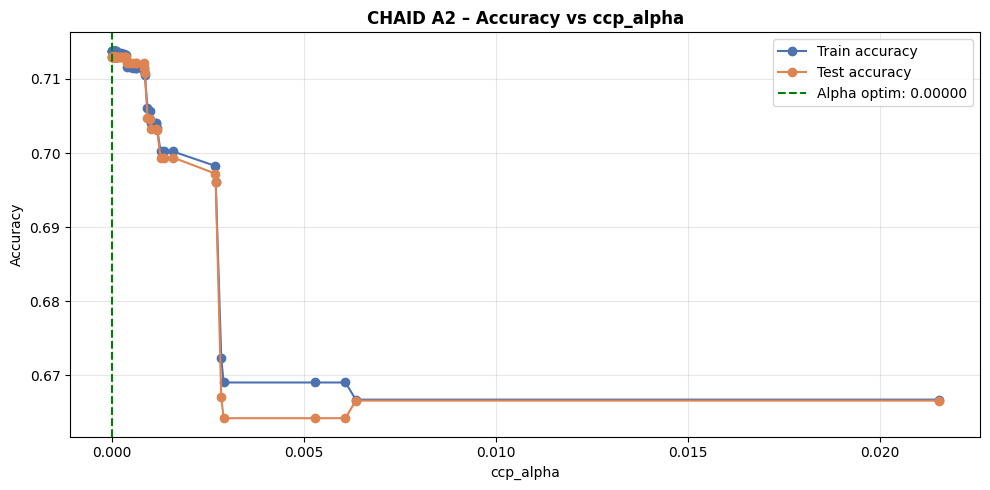

In [22]:
path = chaid_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
train_scores, test_scores = [], []
 
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=7)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))
 
best_alpha = ccp_alphas[np.argmax(test_scores)]
print(f"Alpha optim: {best_alpha:.6f}")
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas, train_scores, 'o-', label='Train accuracy', color='#4C72B0')
ax.plot(ccp_alphas, test_scores,'o-', label='Test accuracy',  color='#DD8452')
ax.axvline(best_alpha, color='green', linestyle='--', label=f'Alpha optim: {best_alpha:.5f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('CHAID A2 – Accuracy vs ccp_alpha', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

-   alpha e 0, nu se aplica nicio penalizare 

-   arborele ramane la dimensiunea sa maxima asa cum a fost construit initial pe datele de antrenament

In [24]:
chaid_pruned = DecisionTreeClassifier(
    criterion='entropy',
    ccp_alpha=best_alpha,
    min_samples_leaf=30,
    min_samples_split=60,
    random_state=7
)
chaid_pruned.fit(X_train, y_train)
 
print(f"Adâncime maximă : {chaid_pruned.get_depth()}")
print(f"Număr noduri : {chaid_pruned.tree_.node_count}")
print(f"Număr frunze : {chaid_pruned.get_n_leaves()}")
print(f"Accuracy train : {chaid_pruned.score(X_train, y_train):.4f}")
print(f"Accuracy test: {chaid_pruned.score(X_test, y_test):.4f}")

Adâncime maximă : 10
Număr noduri : 97
Număr frunze : 49
Accuracy train : 0.7022
Accuracy test: 0.7039


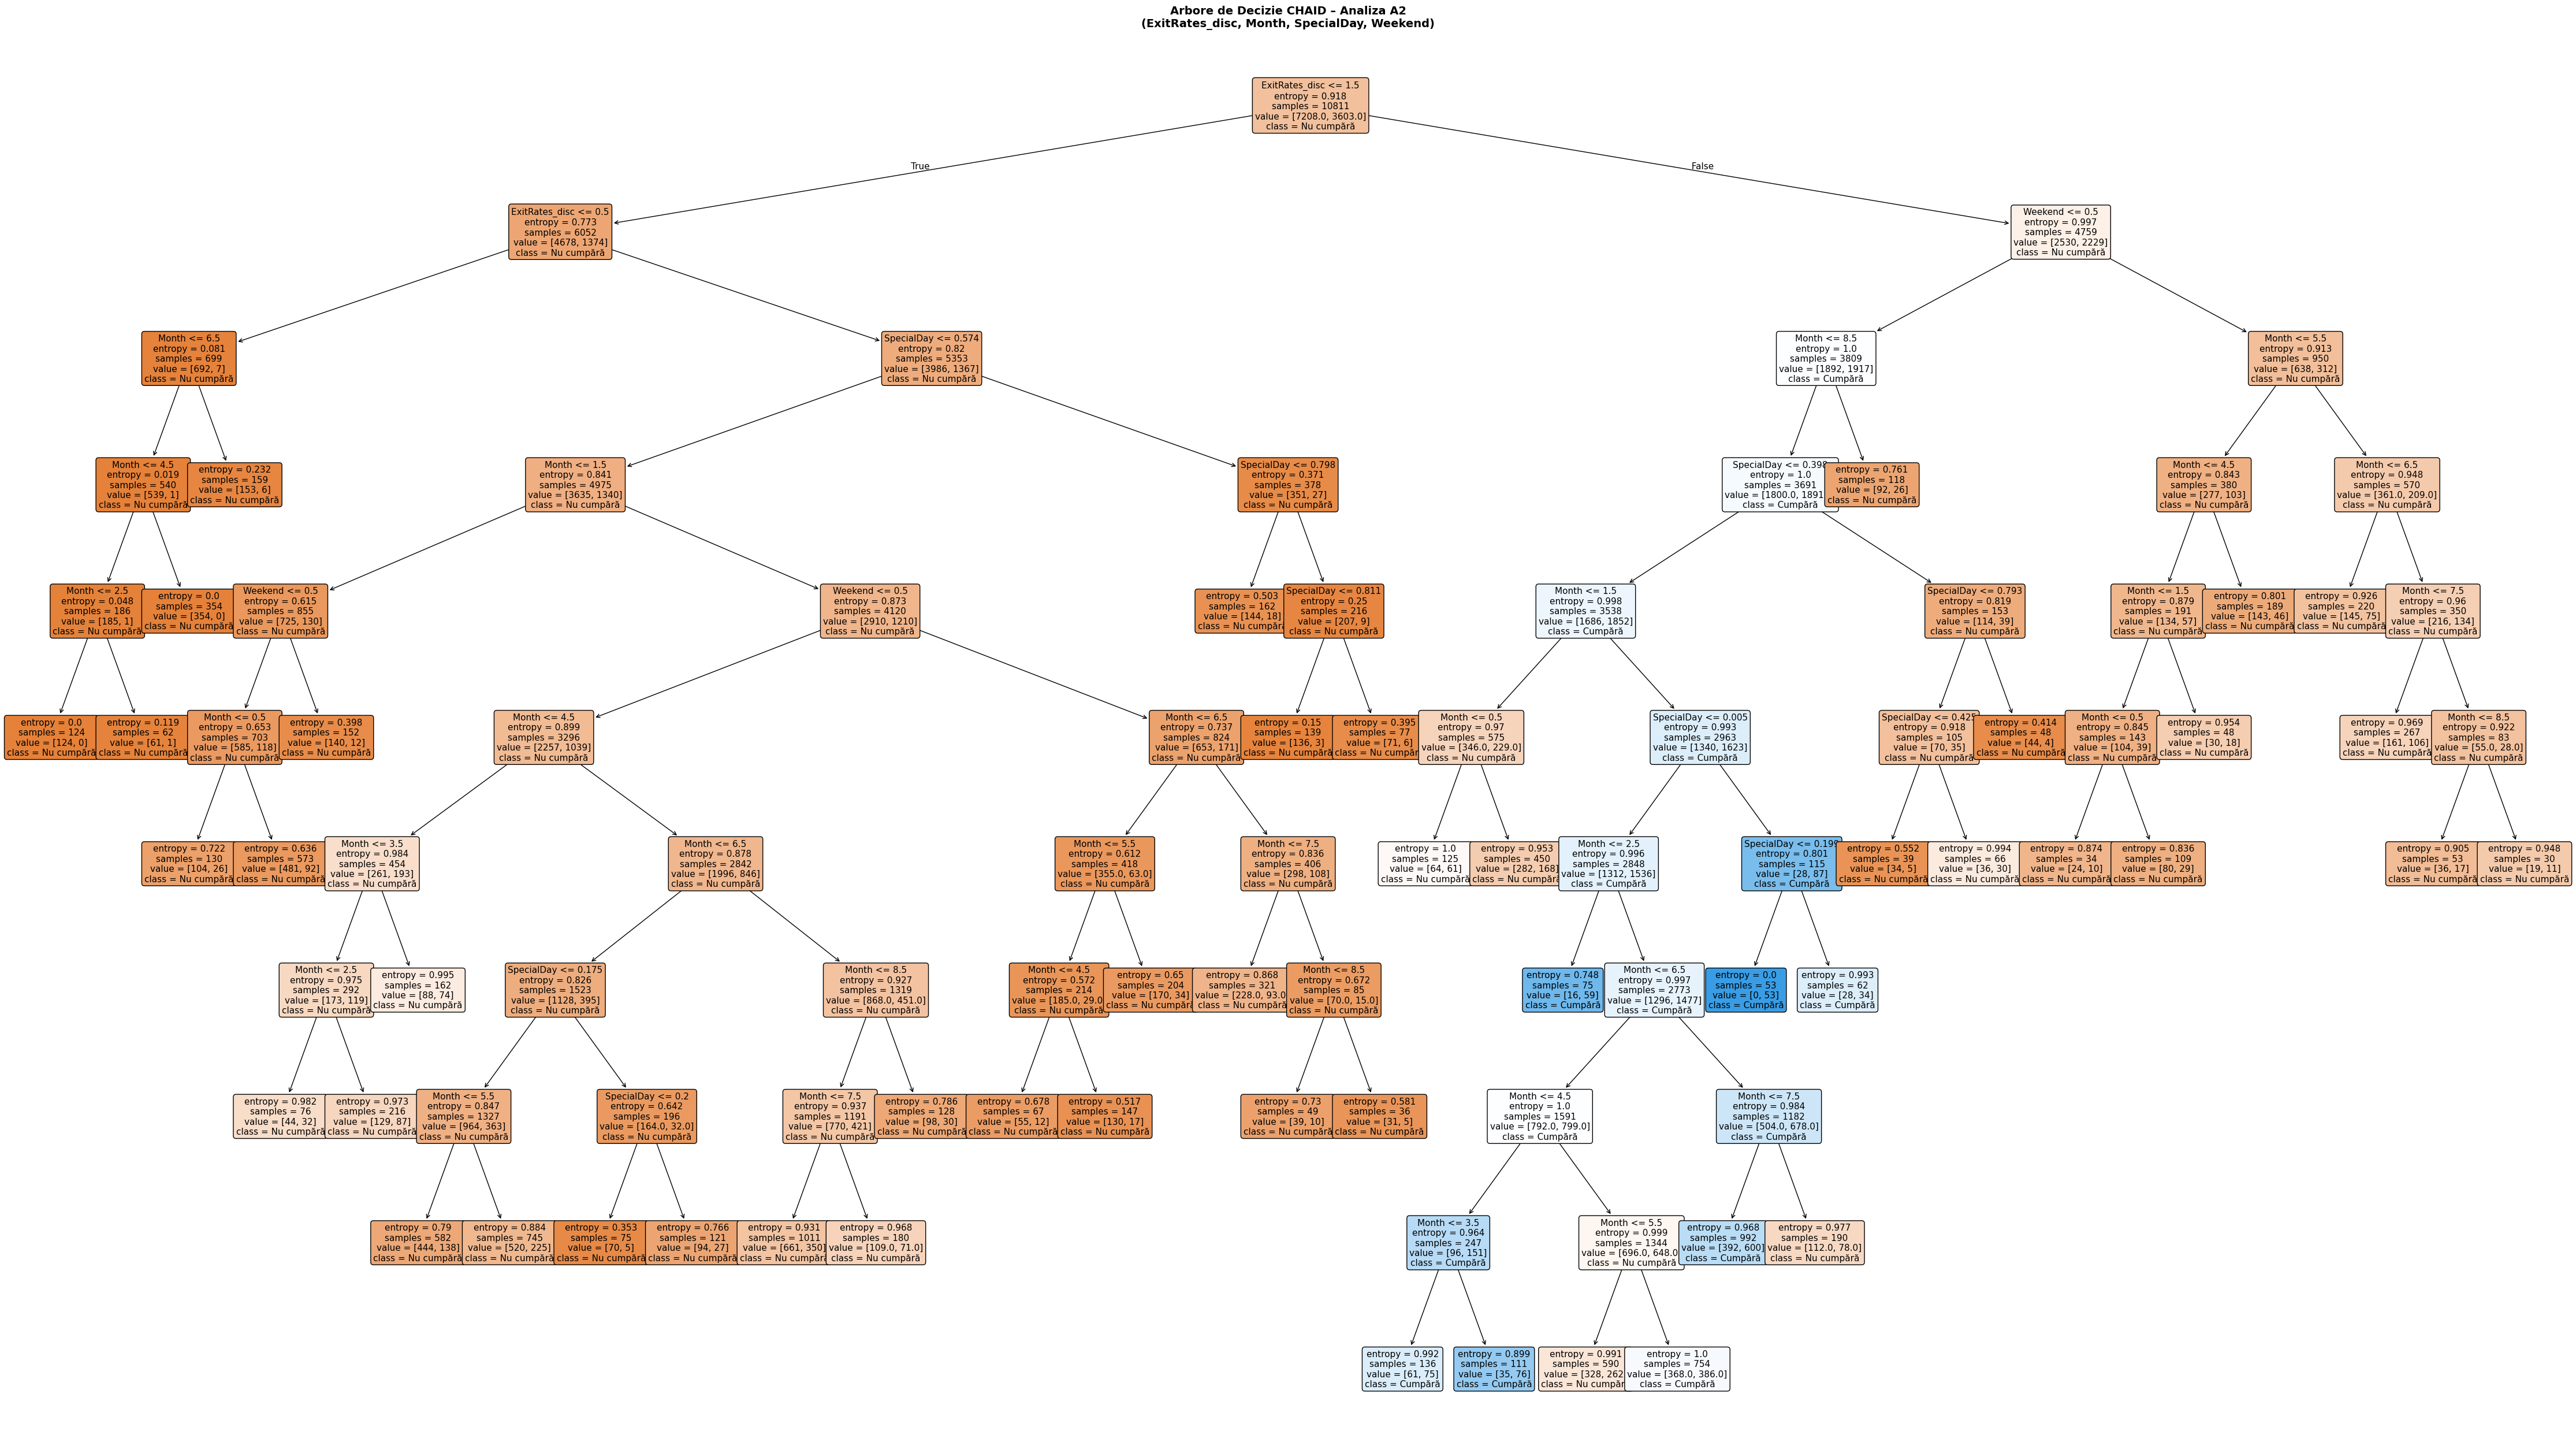

In [33]:
feature_names = X_train.columns.tolist()
class_names   = ['Nu cumpără', 'Cumpără']
 
fig, ax = plt.subplots(figsize=(45
                                , 25))
plot_tree(chaid_pruned,
          feature_names=feature_names,
          class_names=class_names,
          filled=True, rounded=True,
          fontsize=11, ax=ax,
          impurity=True, proportion=False)
ax.set_title('Arbore de Decizie CHAID – Analiza A2\n(ExitRates_disc, Month, SpecialDay, Weekend)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Evaluarea modelului CHAID

In [34]:
y_pred      = chaid_pruned.predict(X_test)
y_pred_prob = chaid_pruned.predict_proba(X_test)[:, 1]
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
  
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)   if (tp + fp) > 0 else 0
recall = tp / (tp + fn)   if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
auc = roc_auc_score(y_test, y_pred_prob)
specificity = tn / (tn + fp)   if (tn + fp) > 0 else 0
 
print(f"\nMETRICI DE PERFORMANȚĂ:")
print(f"{'Accuracy':<20}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"{'Precision':<20}: {precision:.4f}")
print(f"{'Recall (Sensitivity)':<20}: {recall:.4f}")
print(f"{'Specificity':<20}: {specificity:.4f}")
print(f"{'F1-Score':<20}: {f1:.4f}")
print(f"{'AUC-ROC':<20}: {auc:.4f}")
 
cv_scores = cross_val_score(chaid_pruned, X_train, y_train, cv=10, scoring='f1')
print(f"\nCROSS-VALIDATION (10-fold) F1:")
print(f"Scoruri: {cv_scores.round(4)}")
print(f"Medie: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


METRICI DE PERFORMANȚĂ:
Accuracy            : 0.7039  (70.39%)
Precision           : 0.5911
Recall (Sensitivity): 0.3631
Specificity         : 0.8744
F1-Score            : 0.4499
AUC-ROC             : 0.7292

CROSS-VALIDATION (10-fold) F1:
Scoruri: [0.4281 0.4371 0.4295 0.4682 0.4557 0.4607 0.436  0.443  0.4181 0.4587]
Medie: 0.4435 ± 0.0157


### Vizualizari Evaluare

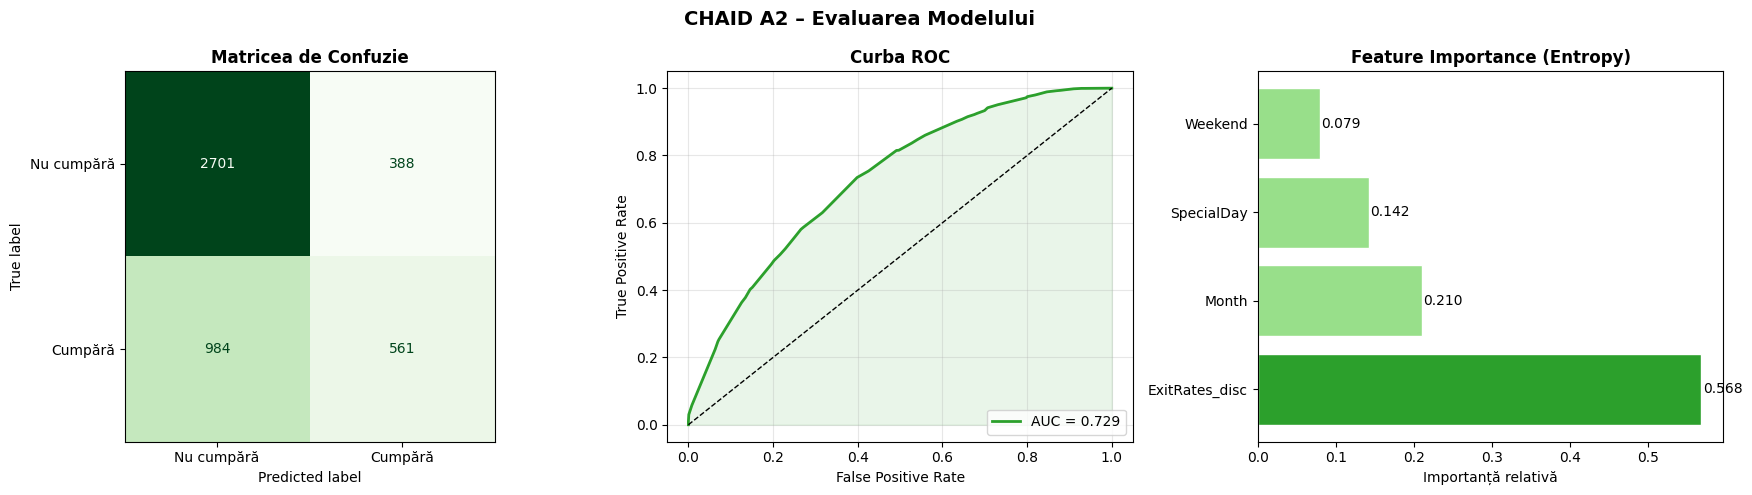

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CHAID A2 – Evaluarea Modelului', fontsize=14, fontweight='bold')
 
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Nu cumpără', 'Cumpără'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Matricea de Confuzie', fontweight='bold')
 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#2ca02c', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2ca02c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curba ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
 
importances = chaid_pruned.feature_importances_
colors = ['#2ca02c' if i == np.argmax(importances) else '#98df8a'
          for i in range(len(importances))]
axes[2].barh(feature_names, importances, color=colors, edgecolor='white')
axes[2].set_title('Feature Importance (Entropy)', fontweight='bold')
axes[2].set_xlabel('Importanță relativă')
for i, v in enumerate(importances):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

### Reguli extrase

In [37]:
rules = export_text(chaid_pruned, feature_names=feature_names)

### Analiza Chi-sq (validare CHAID)

In [40]:
from scipy.stats import chi2_contingency
 
df_test_eval = X_test.copy()
df_test_eval['Revenue'] = y_test.values
 
for col in feature_names:
    ct = pd.crosstab(df_test_eval[col], df_test_eval['Revenue'])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"{col:<35} X_sq={chi2:>10.3f}  p={p:.6f}  {'semnificativ' if p < 0.05 else 'nesemnificativ'}")

ExitRates_disc                      X_sq=   327.995  p=0.000000  semnificativ
Month                               X_sq=   195.302  p=0.000000  semnificativ
SpecialDay                          X_sq=   256.244  p=0.000000  semnificativ
Weekend                             X_sq=    58.807  p=0.000000  semnificativ


### Salvare model + rezultate

In [41]:
joblib.dump(chaid_pruned, '../../data/processed/chaid_a2_model.pkl')
 
results_a2 = {
    'model': 'CHAID', 'analiza': 'A2',
    'features': feature_names,
    'depth': chaid_pruned.get_depth(),
    'n_leaves': chaid_pruned.get_n_leaves(),
    'accuracy': round(accuracy, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1': round(f1, 4),
    'auc': round(auc, 4),
    'cv_f1_mean': round(cv_scores.mean(), 4),
    'cv_f1_std': round(cv_scores.std(), 4)
}
 
pd.DataFrame([results_a2]).to_csv('../../outputs/chaid_a2_results.csv', index=False)

### OBS:

-   CART A1 e mai bun pentru ca a avut PageValues care singur explica o mare parte din variatie

-   CHAID A2 are variabile temporale si comportamentale care sunt semnificative, dar puterea lor predictiva e mai mica in comparatie cu PageValues

-   Recall de 0.36 - modelul rateaza 64% din cumparatorii reali, dar e de asteptat pentru ca variabilele temporale nu sunt suficiente pentru a identifica intentia de cumparare

## QUEST – ANALIZA A3

-   Variabile: ProductRelated_Duration_disc, Region, TrafficType

QUEST (Quick, Unbiased, Efficient Statistical Tree)

-   criteriu selecție variabilă: test F (numeric) sau Chi-Square (categorial)

-   criteriu de split: căutare exhaustivă pe variabila selectată

-   bias redus față de CART (nu favorizează variabile cu multe valori)

-   simulat în sklearn cu criterion='gini' + splitter='best' + max_features=1

(QUEST selectează O singură variabilă per split, fără bias)

In [54]:
train_test_sets = joblib.load('../../data/processed/train_test_sets.pkl')
X_train, X_test, y_train, y_test = train_test_sets['A3_QUEST']
 
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")


Train: (10811, 3) | Test: (4634, 3)


In [55]:
for col in X_train.columns:
    if X_train[col].dtype == 'object' or str(X_train[col].dtype).startswith('String') or X_train[col].dtype == 'str':
        le = LabelEncoder()
        combined = pd.concat([X_train[col], X_test[col]]).astype(str)
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col]  = le.transform(X_test[col].astype(str))
        print(f"  Encodat: {col} -> {dict(zip(le.classes_, le.transform(le.classes_)))}")
 
feature_names = X_train.columns.tolist()


  Encodat: ProductRelated_Duration_disc -> {'Lung': np.int64(0), 'Mediu': np.int64(1), 'Scurt': np.int64(2), 'Zero': np.int64(3)}


In [56]:
X_train.dtypes

ProductRelated_Duration_disc    int64
Region                          int64
TrafficType                     int64
dtype: object

### Selectia Variabilelor - QUEST

-   test F pentru numeric, chi-sq pt categorial

In [57]:
from scipy.stats import f_oneway, chi2_contingency

In [58]:
df_train_eval = X_train.copy()
df_train_eval['Revenue'] = y_train.values
 
for col in feature_names:
    n_unique = df_train_eval[col].nunique()
    if n_unique <= 10:
        ct = pd.crosstab(df_train_eval[col], df_train_eval['Revenue'])
        chi2, p, dof, _ = chi2_contingency(ct)
        print(f"  {col:<40} [Chi-Square] X_sq={chi2:>10.3f}  p-value={p:.6f}  "
              f"{'semnificativ' if p < 0.05 else 'nope'}")
    else:
        group0 = df_train_eval[df_train_eval['Revenue'] == 0][col]
        group1 = df_train_eval[df_train_eval['Revenue'] == 1][col]
        f_stat, p = f_oneway(group0, group1)
        print(f"{col:<40} [F-test] F={f_stat:>10.3f}  p={p:.6f}  "
              f"{'semnificativ' if p < 0.05 else 'nope'}")
 

  ProductRelated_Duration_disc             [Chi-Square] X_sq=   814.141  p-value=0.000000  semnificativ
  Region                                   [Chi-Square] X_sq=   592.237  p-value=0.000000  semnificativ
TrafficType                              [F-test] F=    24.757  p=0.000001  semnificativ


### QUEST FARA PRUNING

In [59]:
quest_full = DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    max_features=None,
    random_state=7
)
quest_full.fit(X_train, y_train)
 
print(f"Adâncime maximă : {quest_full.get_depth()}")
print(f"Număr noduri : {quest_full.tree_.node_count}")
print(f"Număr frunze: {quest_full.get_n_leaves()}")
print(f"Accuracy train: {quest_full.score(X_train, y_train):.4f}")
print(f"Accuracy test : {quest_full.score(X_test, y_test):.4f}")

Adâncime maximă : 17
Număr noduri : 673
Număr frunze: 337
Accuracy train: 0.7262
Accuracy test : 0.7067


## Hyperparm tuning cu GridSearch

-   specific QUEST: adancime limitata + min samples

In [62]:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [63]:
param_grid = {
    'max_depth':[3, 4, 5, 6],
    'min_samples_leaf': [20, 30, 50],
    'min_samples_split':[40, 60, 100],
    'ccp_alpha':  [0.0, 0.001, 0.005, 0.01]
}
 
grid_search = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=7),
    param_grid,
    cv=10,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
 
print(f"Parametri optimi : {grid_search.best_params_}")
print(f"Best CV F1 : {grid_search.best_score_:.4f}")

Parametri optimi : {'ccp_alpha': 0.001, 'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 40}
Best CV F1 : 0.3250


## Arbore QUEST cu parametri optimi

In [64]:
best_params = grid_search.best_params_
quest_final = DecisionTreeClassifier(
    criterion='gini',
    random_state=7,
    **best_params
)
quest_final.fit(X_train, y_train)
 
print(f"Adâncime maximă : {quest_final.get_depth()}")
print(f"Număr noduri : {quest_final.tree_.node_count}")
print(f"Număr frunze : {quest_final.get_n_leaves()}")
print(f"Accuracy train: {quest_final.score(X_train, y_train):.4f}")
print(f"Accuracy test : {quest_final.score(X_test, y_test):.4f}")

Adâncime maximă : 6
Număr noduri : 21
Număr frunze : 11
Accuracy train: 0.6976
Accuracy test : 0.6856


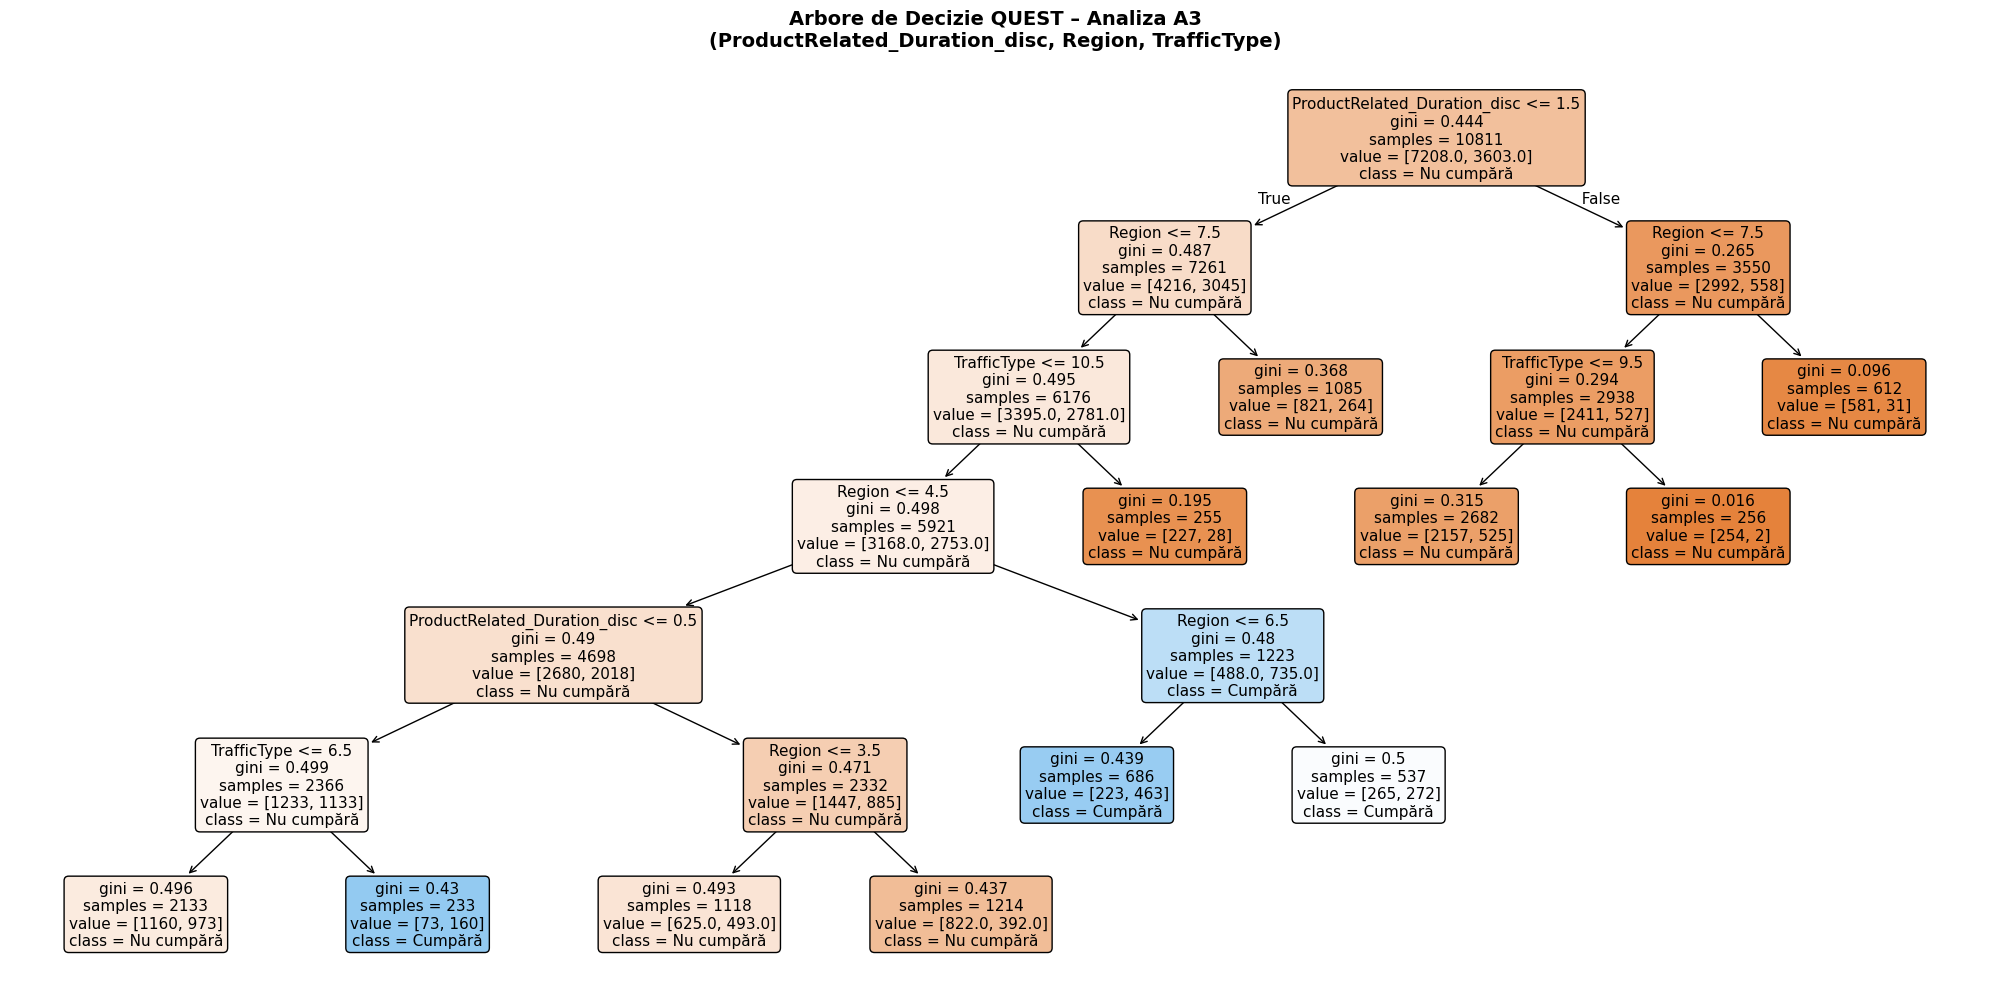

In [65]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(quest_final,
          feature_names=feature_names,
          class_names=['Nu cumpără', 'Cumpără'],
          filled=True, rounded=True,
          fontsize=11, ax=ax,
          impurity=True, proportion=False)
ax.set_title('Arbore de Decizie QUEST – Analiza A3\n'
             '(ProductRelated_Duration_disc, Region, TrafficType)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### Evaluarea modelului

In [66]:
y_pred = quest_final.predict(X_test)
y_pred_prob = quest_final.predict_proba(X_test)[:, 1]
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
 
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)   if (tp + fp) > 0 else 0
recall = tp / (tp + fn)   if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
auc = roc_auc_score(y_test, y_pred_prob)
specificity = tn / (tn + fp)   if (tn + fp) > 0 else 0
 
print(f"\n  METRICI DE PERFORMANȚĂ:")
print(f"{'Accuracy':<20}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"{'Precision':<20}: {precision:.4f}")
print(f" {'Recall (Sensitivity)':<20}: {recall:.4f}")
print(f"{'Specificity':<20}: {specificity:.4f}")
print(f"{'F1-Score':<20}: {f1:.4f}")
print(f"{'AUC-ROC':<20}: {auc:.4f}")
 
cv_scores = cross_val_score(quest_final, X_train, y_train, cv=10, scoring='f1')
print(f"\nCROSS-VALIDATION (10-fold) F1:")
print(f"Scoruri: {cv_scores.round(4)}")
print(f"Medie  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  METRICI DE PERFORMANȚĂ:
Accuracy            : 0.6856  (68.56%)
Precision           : 0.5712
 Recall (Sensitivity): 0.2285
Specificity         : 0.9142
F1-Score            : 0.3264
AUC-ROC             : 0.6960

CROSS-VALIDATION (10-fold) F1:
Scoruri: [0.2819 0.3671 0.3373 0.3431 0.3553 0.2969 0.3633 0.2992 0.3095 0.2963]
Medie  : 0.3250 ± 0.0300


In [67]:
y_pred = quest_full.predict(X_test)
y_pred_prob = quest_full.predict_proba(X_test)[:, 1]
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
 
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)   if (tp + fp) > 0 else 0
recall = tp / (tp + fn)   if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
auc = roc_auc_score(y_test, y_pred_prob)
specificity = tn / (tn + fp)   if (tn + fp) > 0 else 0
 
print(f"\n  METRICI DE PERFORMANȚĂ:")
print(f"{'Accuracy':<20}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"{'Precision':<20}: {precision:.4f}")
print(f" {'Recall (Sensitivity)':<20}: {recall:.4f}")
print(f"{'Specificity':<20}: {specificity:.4f}")
print(f"{'F1-Score':<20}: {f1:.4f}")
print(f"{'AUC-ROC':<20}: {auc:.4f}")
 
cv_scores = cross_val_score(quest_full, X_train, y_train, cv=10, scoring='f1')
print(f"\nCROSS-VALIDATION (10-fold) F1:")
print(f"Scoruri: {cv_scores.round(4)}")
print(f"Medie  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  METRICI DE PERFORMANȚĂ:
Accuracy            : 0.7067  (70.67%)
Precision           : 0.5979
 Recall (Sensitivity): 0.3676
Specificity         : 0.8763
F1-Score            : 0.4553
AUC-ROC             : 0.7252

CROSS-VALIDATION (10-fold) F1:
Scoruri: [0.4456 0.411  0.413  0.4828 0.469  0.4298 0.4057 0.408  0.4441 0.4536]
Medie  : 0.4363 ± 0.0257


### Vizualizare evaluare

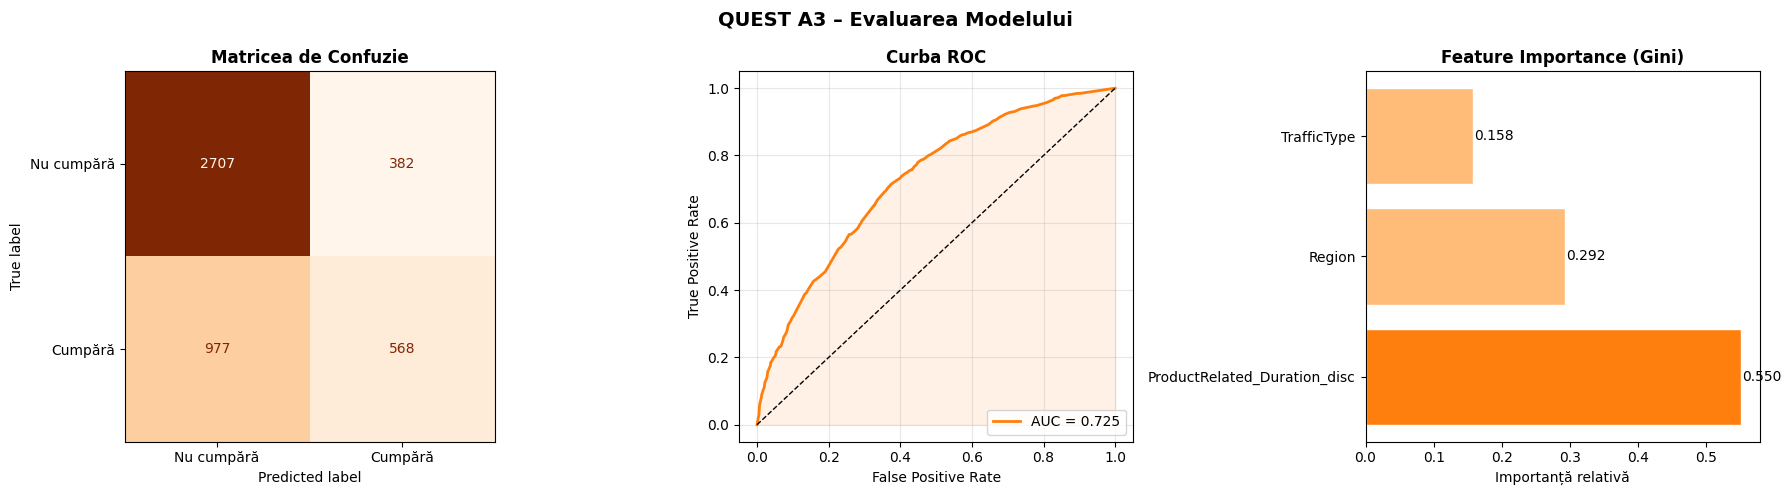

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('QUEST A3 – Evaluarea Modelului', fontsize=14, fontweight='bold')
 
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Nu cumpără', 'Cumpără'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Matricea de Confuzie', fontweight='bold')
 
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#ff7f0e', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#ff7f0e')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curba ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)
 
importances = quest_final.feature_importances_
colors = ['#ff7f0e' if i == np.argmax(importances) else '#ffbb78'
          for i in range(len(importances))]
axes[2].barh(feature_names, importances, color=colors, edgecolor='white')
axes[2].set_title('Feature Importance (Gini)', fontweight='bold')
axes[2].set_xlabel('Importanță relativă')
for i, v in enumerate(importances):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

### Reguli extrase

In [69]:
rules = export_text(quest_final, feature_names=feature_names)

### QUEST fara GridSearch vs CU GridSearch

-   GridSearch a găsit parametri care au over-restricționat arborele — prea mult pruning, prea puține split-uri -> modelul a devenit prea simplu și a pierdut putere predictivă

-   Fara GridSearch e mai bun

### Salvare model

In [70]:
y_pred = quest_full.predict(X_test)
y_pred_prob = quest_full.predict_proba(X_test)[:, 1]
 
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
 
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)   if (tp + fp) > 0 else 0
recall = tp / (tp + fn)   if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
auc = roc_auc_score(y_test, y_pred_prob)
specificity = tn / (tn + fp)   if (tn + fp) > 0 else 0
 
print(f"\n  METRICI DE PERFORMANȚĂ:")
print(f"{'Accuracy':<20}: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"{'Precision':<20}: {precision:.4f}")
print(f" {'Recall (Sensitivity)':<20}: {recall:.4f}")
print(f"{'Specificity':<20}: {specificity:.4f}")
print(f"{'F1-Score':<20}: {f1:.4f}")
print(f"{'AUC-ROC':<20}: {auc:.4f}")
 
cv_scores = cross_val_score(quest_full, X_train, y_train, cv=10, scoring='f1')
print(f"\nCROSS-VALIDATION (10-fold) F1:")
print(f"Scoruri: {cv_scores.round(4)}")
print(f"Medie  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  METRICI DE PERFORMANȚĂ:
Accuracy            : 0.7067  (70.67%)
Precision           : 0.5979
 Recall (Sensitivity): 0.3676
Specificity         : 0.8763
F1-Score            : 0.4553
AUC-ROC             : 0.7252

CROSS-VALIDATION (10-fold) F1:
Scoruri: [0.4456 0.411  0.413  0.4828 0.469  0.4298 0.4057 0.408  0.4441 0.4536]
Medie  : 0.4363 ± 0.0257


In [71]:
joblib.dump(quest_full, '../../data/processed/quest_a3_model.pkl')
 
results_a3 = {
    'model': 'QUEST', 'analiza': 'A3',
    'features': feature_names,
    'depth': quest_full.get_depth(),
    'n_leaves': quest_full.get_n_leaves(),
    'accuracy': round(accuracy, 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1': round(f1, 4),
    'auc': round(auc, 4),
    'cv_f1_mean': round(cv_scores.mean(), 4),
    'cv_f1_std': round(cv_scores.std(), 4)
}
 
pd.DataFrame([results_a3]).to_csv('../../outputs/quest_a3_results.csv', index=False)